In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, SimpleRNN, LSTM, GRU,
    Bidirectional, Dropout, Input
)
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/nvidia.csv")

In [3]:
df["Date"] = pd.to_datetime(df["Date"])

In [4]:
df = df.sort_values("Date").reset_index(drop=True)

In [5]:
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2023-01-03,14.851,14.996,14.096,14.315,401277000,14.305581
1,2023-01-04,14.567,14.853,14.241,14.749,431324000,14.739295
2,2023-01-05,14.491,14.564,14.148,14.265,389168000,14.255614
3,2023-01-06,14.474,15.010,14.034,14.859,405044000,14.849225
4,2023-01-09,15.284,16.056,15.141,15.628,504231000,15.617719


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 448 entries, 0 to 447
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       448 non-null    datetime64[us]
 1   Open       448 non-null    float64       
 2   High       448 non-null    float64       
 3   Low        448 non-null    float64       
 4   Close      448 non-null    float64       
 5   Volume     448 non-null    int64         
 6   Adj Close  448 non-null    float64       
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 24.6 KB


In [7]:
df.describe()

,Date,Open,High,Low,Close,Volume,Adj Close
count,448,448.000000,448.000000,448.000000,448.000000,4.480000e+02,448.000000
mean,2023-11-23 17:02:08.571428,64.193085,65.402489,62.910025,64.237370,4.504371e+08,64.224244
min,2023-01-03 00:00:00,14.474000,14.564000,14.034000,14.265000,1.697320e+08,14.255614
25%,2023-06-13 18:00:00,40.477000,41.179751,39.845001,40.456500,3.547021e+08,40.444264
50%,2023-11-21 12:00:00,48.164499,48.571501,47.447500,48.043001,4.246520e+08,48.032696
75%,2024-05-03 18:00:00,91.065750,92.465750,89.209751,91.375751,5.124520e+08,91.360435
max,2024-10-14 00:00:00,139.800003,140.759995,136.300003,138.850601,1.543911e+09,138.850601
std,NaN,35.880173,36.613675,34.981482,35.825875,1.596547e+08,35.827486


In [8]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close'], dtype='str')

In [9]:
df.dtypes

Date         datetime64[us]
Open                float64
High                float64
Low                 float64
Close               float64
Volume                int64
Adj Close           float64
dtype: object

In [10]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Volume       0
Adj Close    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.nunique()

Date         448
Open         442
High         444
Low          444
Close        446
Volume       448
Adj Close    446
dtype: int64

In [13]:
print(f"\nDataset: {df.shape[0]} days, from {df['Date'].min().date()} to {df['Date'].max().date()}")


Dataset: 448 days, from 2023-01-03 to 2024-10-14


In [14]:
df.shape

(448, 7)

In [15]:
data = df[["Close"]].values

In [16]:
# normalization to the interval [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

In [17]:
# generating sequences, 60 days to predict day 61
SEQ_LEN = 60

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, SEQ_LEN)

In [18]:
# train/test: 80/20
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [19]:
# reshape for RNN: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

In [20]:
print(f"\nTraining data: {X_train.shape}")
print(f"Testing data: {X_test.shape}")


Training data: (310, 60, 1)
Testing data: (78, 60, 1)


In [21]:
# 3. function for training and evaluation
def build_and_evaluate(model, model_name, X_train, y_train, X_test, y_test, scaler, epochs=50):
    print(f"  Model: {model_name}")

    early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )
    print(f"Trained for {len(history.history['loss'])} epochs (early stopping)")

    # predictions
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_real = scaler.inverse_transform(y_test.reshape(-1, 1))

    # metrics
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    print(f"  RMSE: {rmse:.4f} USD")
    print(f"  MAE:  {mae:.4f} USD")

    return history, y_pred, y_real, rmse, mae

In [22]:
# 4. MODEL 1 - SimpleRNN
model_rnn = Sequential([
    Input(shape=(SEQ_LEN, 1)),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(1)
])
model_rnn.compile(optimizer="adam", loss="mse")

history_rnn, pred_rnn, y_real, rmse_rnn, mae_rnn = build_and_evaluate(
    model_rnn, "SimpleRNN", X_train, y_train, X_test, y_test, scaler
)


  Model: SimpleRNN
Trained for 14 epochs (early stopping)
  RMSE: 5.6465 USD
  MAE:  4.5857 USD


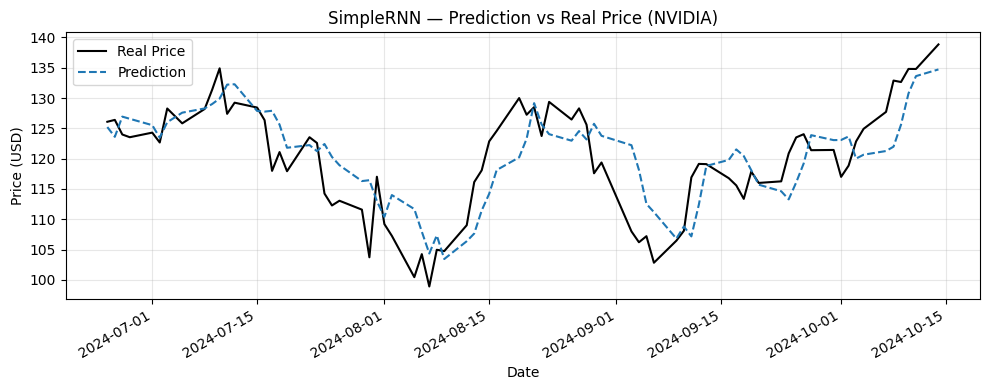

In [23]:
# grafic SimpleRNN — predictions vs real values
dates_test = df["Date"].values[SEQ_LEN + split:]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates_test, y_real, label="Real Price", color="black", linewidth=1.5)
ax.plot(dates_test, pred_rnn, label="Prediction", color="tab:blue", linewidth=1.5, linestyle="--")
ax.set_title("SimpleRNN — Prediction vs Real Price (NVIDIA)", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

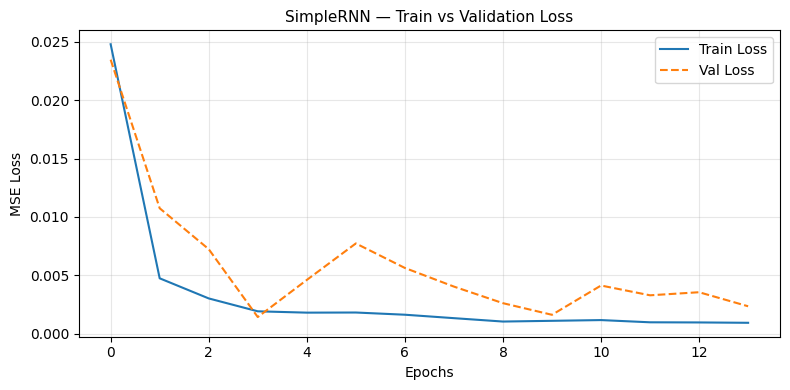

In [24]:
# grafic Loss — SimpleRNN
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_rnn.history["loss"], label="Train Loss", linewidth=1.5)
ax.plot(history_rnn.history["val_loss"], label="Val Loss", linewidth=1.5, linestyle="--")
ax.set_title("SimpleRNN — Train vs Validation Loss", fontsize=11)
ax.set_xlabel("Epochs")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# 5. MODEL 2 - LSTM
model_lstm = Sequential([
    Input(shape=(SEQ_LEN, 1)),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(1)
])
model_lstm.compile(optimizer="adam", loss="mse")

history_lstm, pred_lstm, _, rmse_lstm, mae_lstm = build_and_evaluate(
    model_lstm, "LSTM", X_train, y_train, X_test, y_test, scaler
)

  Model: LSTM
Trained for 36 epochs (early stopping)
  RMSE: 7.7944 USD
  MAE:  6.2088 USD


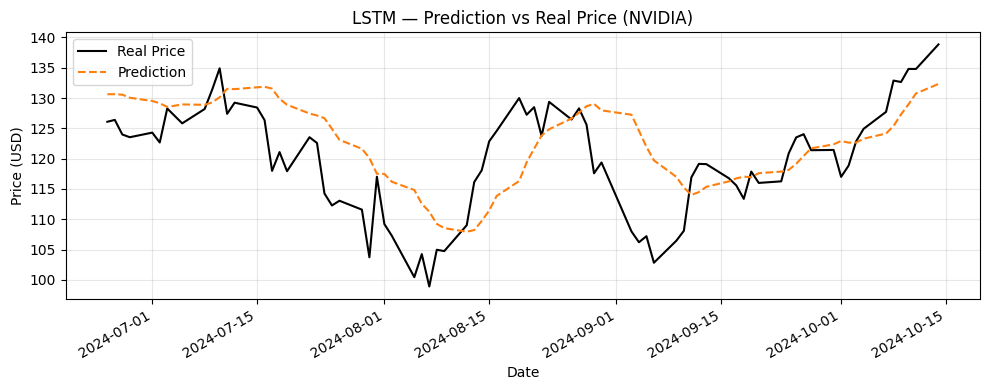

In [26]:
# grafic LSTM
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates_test, y_real, label="Real Price", color="black", linewidth=1.5)
ax.plot(dates_test, pred_lstm, label="Prediction", color="tab:orange", linewidth=1.5, linestyle="--")
ax.set_title("LSTM — Prediction vs Real Price (NVIDIA)", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

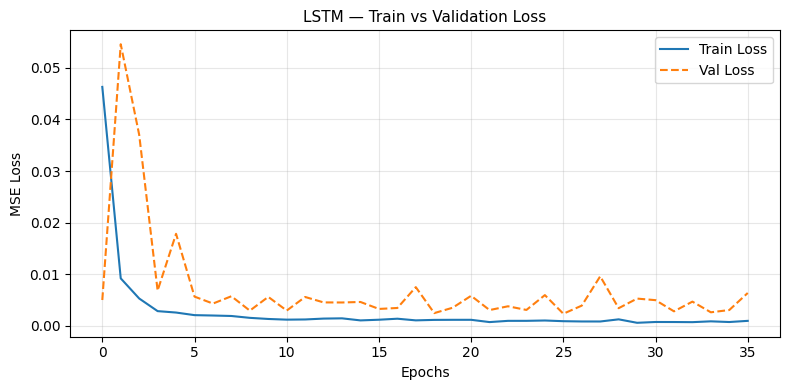

In [27]:
# grafic Loss — LSTM
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_lstm.history["loss"], label="Train Loss", linewidth=1.5)
ax.plot(history_lstm.history["val_loss"], label="Val Loss", linewidth=1.5, linestyle="--")
ax.set_title("LSTM — Train vs Validation Loss", fontsize=11)
ax.set_xlabel("Epochs")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# 6. MODEL 3 - GRU
model_gru = Sequential([
    Input(shape=(SEQ_LEN, 1)),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(1)
])
model_gru.compile(optimizer="adam", loss="mse")

history_gru, pred_gru, _, rmse_gru, mae_gru = build_and_evaluate(
    model_gru, "GRU", X_train, y_train, X_test, y_test, scaler
)


  Model: GRU
Trained for 18 epochs (early stopping)
  RMSE: 5.9459 USD
  MAE:  4.8000 USD


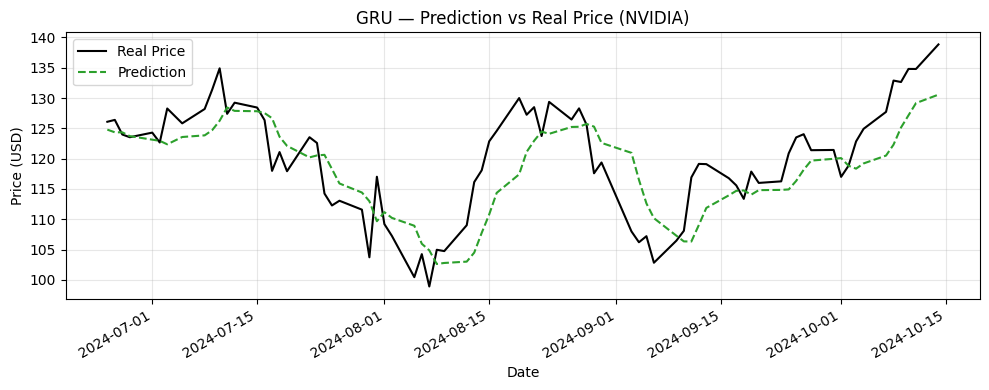

In [29]:
# grafic GRU
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates_test, y_real, label="Real Price", color="black", linewidth=1.5)
ax.plot(dates_test, pred_gru, label="Prediction", color="tab:green", linewidth=1.5, linestyle="--")
ax.set_title("GRU — Prediction vs Real Price (NVIDIA)", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

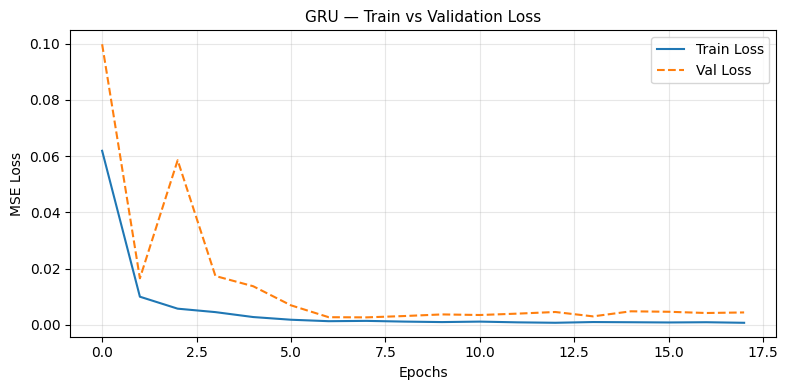

In [30]:
# grafic Loss — GRU
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_gru.history["loss"], label="Train Loss", linewidth=1.5)
ax.plot(history_gru.history["val_loss"], label="Val Loss", linewidth=1.5, linestyle="--")
ax.set_title("GRU — Train vs Validation Loss", fontsize=11)
ax.set_xlabel("Epochs")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# 7. MODEL 4 - Bidirectional LSTM
model_bilstm = Sequential([
    Input(shape=(SEQ_LEN, 1)),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(1)
])
model_bilstm.compile(optimizer="adam", loss="mse")

history_bilstm, pred_bilstm, _, rmse_bilstm, mae_bilstm = build_and_evaluate(
    model_bilstm, "Bidirectional LSTM", X_train, y_train, X_test, y_test, scaler
)

  Model: Bidirectional LSTM
Trained for 26 epochs (early stopping)
  RMSE: 11.4340 USD
  MAE:  9.4028 USD


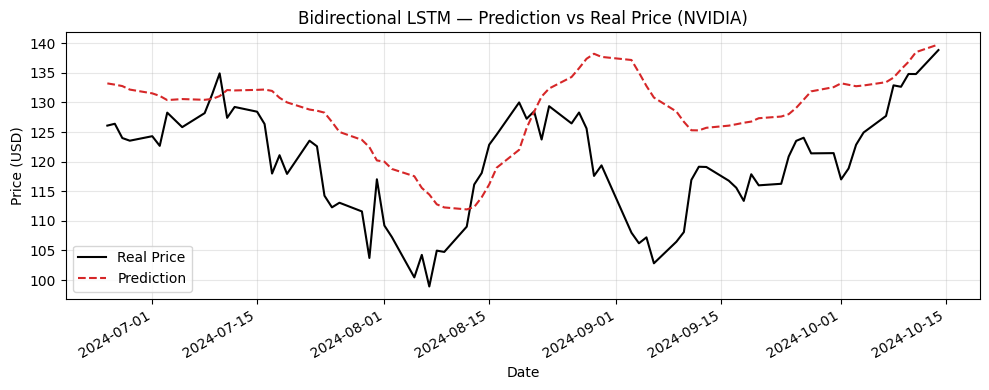

In [32]:
# grafic Bidirectional LSTM
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates_test, y_real, label="Real Price", color="black", linewidth=1.5)
ax.plot(dates_test, pred_bilstm, label="Prediction", color="tab:red", linewidth=1.5, linestyle="--")
ax.set_title("Bidirectional LSTM — Prediction vs Real Price (NVIDIA)", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

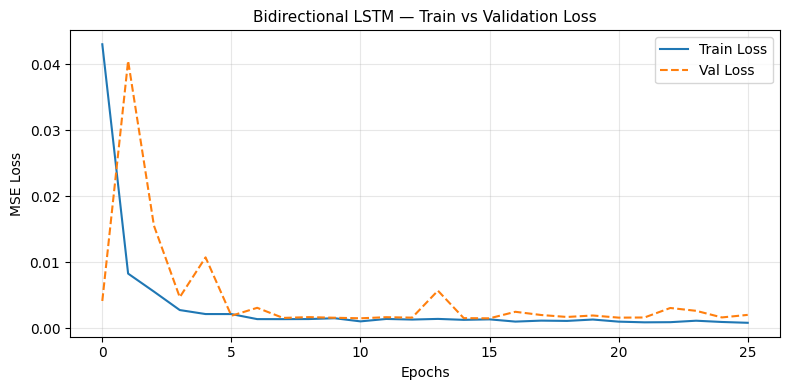

In [33]:
# grafic Loss — Bidirectional LSTM
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_bilstm.history["loss"], label="Train Loss", linewidth=1.5)
ax.plot(history_bilstm.history["val_loss"], label="Val Loss", linewidth=1.5, linestyle="--")
ax.set_title("Bidirectional LSTM — Train vs Validation Loss", fontsize=11)
ax.set_xlabel("Epochs")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# 8. MODEL 5 - Bidirectional GRU
model_bigru = Sequential([
    Input(shape=(SEQ_LEN, 1)),
    Bidirectional(GRU(64, return_sequences=False)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(1)
])
model_bigru.compile(optimizer="adam", loss="mse")

history_bigru, pred_bigru, _, rmse_bigru, mae_bigru = build_and_evaluate(
    model_bigru, "Bidirectional GRU", X_train, y_train, X_test, y_test, scaler
)


  Model: Bidirectional GRU
Trained for 17 epochs (early stopping)
  RMSE: 12.5243 USD
  MAE:  10.0206 USD


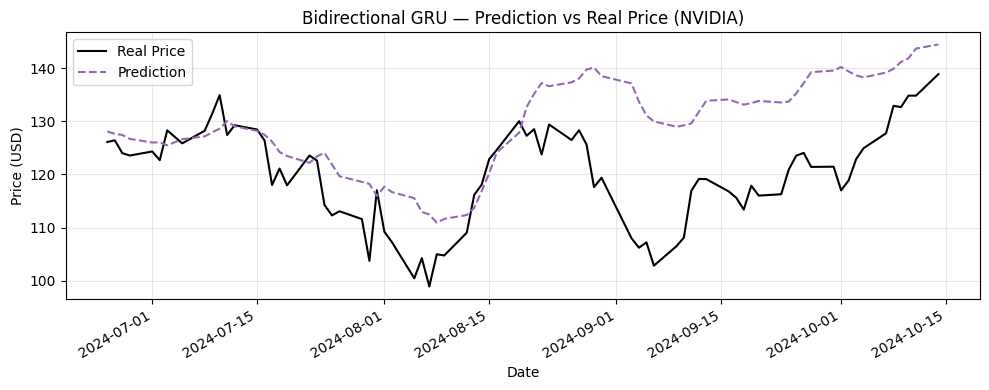

In [35]:
# grafic Bidirectional GRU
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates_test, y_real, label="Real Price", color="black", linewidth=1.5)
ax.plot(dates_test, pred_bigru, label="Prediction", color="tab:purple", linewidth=1.5, linestyle="--")
ax.set_title("Bidirectional GRU — Prediction vs Real Price (NVIDIA)", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

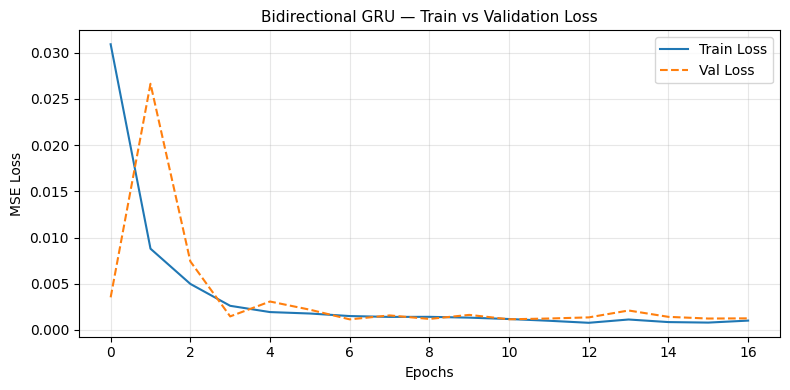

In [36]:
# grafic Loss — Bidirectional GRU
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_bigru.history["loss"], label="Train Loss", linewidth=1.5)
ax.plot(history_bigru.history["val_loss"], label="Val Loss", linewidth=1.5, linestyle="--")
ax.set_title("Bidirectional GRU — Train vs Validation Loss", fontsize=11)
ax.set_xlabel("Epochs")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
# 9. comparing models

print("  COMPARAREA MODELELOR")
print(f"{'Model':<25} {'RMSE (USD)':>12} {'MAE (USD)':>12}")
results = [
    ("SimpleRNN",          rmse_rnn,    mae_rnn),
    ("LSTM",               rmse_lstm,   mae_lstm),
    ("GRU",                rmse_gru,    mae_gru),
    ("Bidirectional LSTM", rmse_bilstm, mae_bilstm),
    ("Bidirectional GRU",  rmse_bigru,  mae_bigru),
]
for name, rmse, mae in results:
    print(f"  {name:<23} {rmse:>12.4f} {mae:>12.4f}")

best = min(results, key=lambda x: x[1])
print(f"\n  Cel mai bun model (RMSE minim): {best[0]} — RMSE = {best[1]:.4f} USD")

  COMPARAREA MODELELOR
Model                       RMSE (USD)    MAE (USD)
  SimpleRNN                     5.6465       4.5857
  LSTM                          7.7944       6.2088
  GRU                           5.9459       4.8000
  Bidirectional LSTM           11.4340       9.4028
  Bidirectional GRU            12.5243      10.0206

  Cel mai bun model (RMSE minim): SimpleRNN — RMSE = 5.6465 USD


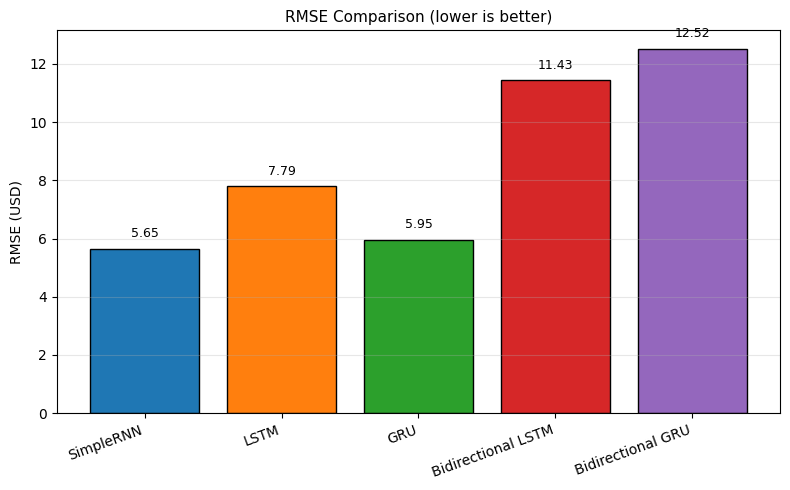

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))
model_names = [r[0] for r in results]
rmse_vals   = [r[1] for r in results]
colors_bar  = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
bars = ax.bar(model_names, rmse_vals, color=colors_bar, edgecolor="black")
ax.set_title("RMSE Comparison (lower is better)", fontsize=11)
ax.set_ylabel("RMSE (USD)")
ax.set_xticklabels(model_names, rotation=20, ha="right")
for bar, val in zip(bars, rmse_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

In [39]:
# 11. prediction in real time (with last 60 days from dataset)
print(" Prediction in real time ")

last_60 = data_scaled[-SEQ_LEN:]
input_seq = last_60.reshape(1, SEQ_LEN, 1)

for name, model in [("SimpleRNN", model_rnn), ("LSTM", model_lstm), ("GRU", model_gru),
                     ("Bidir. LSTM", model_bilstm), ("Bidir. GRU", model_bigru)]:
    pred_tomorrow = scaler.inverse_transform(model.predict(input_seq, verbose=0))
    print(f"  {name:<20} → Prediction for tomorrow: ${pred_tomorrow[0][0]:.2f} USD")

last_real = scaler.inverse_transform([[data_scaled[-1][0]]])[0][0]
print(f"\n  Last real price in dataset: ${last_real:.2f} USD")


 Prediction in real time 
  SimpleRNN            → Prediction for tomorrow: $135.37 USD
  LSTM                 → Prediction for tomorrow: $134.34 USD
  GRU                  → Prediction for tomorrow: $132.67 USD
  Bidir. LSTM          → Prediction for tomorrow: $141.51 USD
  Bidir. GRU           → Prediction for tomorrow: $146.07 USD

  Last real price in dataset: $138.85 USD
